# Sección 4. Red bipartita autor-video

La red representa la participación observada en los comentarios recolectados. Se conservan todos los autores, videos y enlaces presentes en la muestra.

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from IPython.display import Markdown, display

import eda
import red

FIGURAS = REPO / "outputs" / "figuras"
TABLAS = REPO / "outputs" / "tablas"
FIGURAS.mkdir(parents=True, exist_ok=True)
TABLAS.mkdir(parents=True, exist_ok=True)

videos, comments = eda.cargar_procesados()
B = red.build_bipartita(comments)
autores = [n for n, d in B.nodes(data=True) if d["tipo"] == "autor"]
videos_red = [n for n, d in B.nodes(data=True) if d["tipo"] == "video"]

assert nx.algorithms.bipartite.is_bipartite(B)
assert sum(d["weight"] for _, _, d in B.edges(data=True)) == len(comments)

display(Markdown(
    f"**Resultado 4.1.** La red no dirigida contiene **{B.number_of_nodes()} nodos**: "
    f"**{len(autores)} autores** y **{len(videos_red)} videos**. "
    f"Sus **{B.number_of_edges()} aristas** corresponden a pares autor-video distintos."
))

**Resultado 4.1.** La red no dirigida contiene **351 nodos**: **332 autores** y **19 videos**. Sus **343 aristas** corresponden a pares autor-video distintos.

## 4.1 y 4.2. Construcción y pesos

Cada arista une un `author_channel_id` con un `video_id`. Su peso es la cantidad de comentarios de ese autor en ese video.

In [2]:
pesos = pd.Series([d["weight"] for _, _, d in B.edges(data=True)])
pares_repetidos = int((pesos > 1).sum())

display(pd.DataFrame({
    "medida": ["aristas", "suma de pesos", "aristas con peso mayor que 1", "peso máximo"],
    "valor": [B.number_of_edges(), int(pesos.sum()), pares_repetidos, int(pesos.max())],
}))
display(Markdown(
    f"Los pesos suman **{int(pesos.sum())}**, igual al número de comentarios. "
    f"Hay **{pares_repetidos} pares** con más de un comentario y el peso máximo es **{int(pesos.max())}**."
))

,medida,valor
0,aristas,343
1,suma de pesos,406
2,aristas con peso mayor que 1,40
3,peso máximo,6


Los pesos suman **406**, igual al número de comentarios. Hay **40 pares** con más de un comentario y el peso máximo es **6**.

## 4.3. Tablas de nodos y aristas

In [3]:
videos_atributos = videos.set_index("video_id")
filas_nodos = []
for node, data in B.nodes(data=True):
    fila = {
        "id": node,
        "tipo": data["tipo"],
        "n_comentarios": data["n_comentarios"],
        "author_name": data.get("author_name", ""),
        "author_handle": data.get("author_handle", ""),
        "n_videos": data.get("n_videos", pd.NA),
        "title": "",
        "channel_id": data.get("channel_id", ""),
        "channel_name": data.get("channel_name", ""),
        "category": "",
        "view_count": pd.NA,
        "n_autores": data.get("n_autores", pd.NA),
    }
    if data["tipo"] == "video":
        atributos = videos_atributos.loc[node]
        fila.update({
            "title": atributos["title"],
            "channel_id": atributos["channel_id"],
            "channel_name": atributos["channel_name"],
            "category": atributos["category"],
            "view_count": atributos["view_count"],
        })
    filas_nodos.append(fila)

nodos = pd.DataFrame(filas_nodos).sort_values(["tipo", "id"]).reset_index(drop=True)
aristas = pd.DataFrame(
    [{"source": a, "target": v, "weight": d["weight"]} for a, v, d in B.edges(data=True)]
).sort_values(["source", "target"]).reset_index(drop=True)

nodos.to_csv(TABLAS / "nodos.csv", index=False)
aristas.to_csv(TABLAS / "aristas.csv", index=False)

assert len(nodos) == B.number_of_nodes()
assert len(aristas) == B.number_of_edges()
assert int(aristas["weight"].sum()) == len(comments)

display(nodos.groupby("tipo").size().rename("nodos").to_frame())
display(aristas.head())

,nodos
tipo,
autor,332
video,19


,source,target,weight
0,UC-HeUTT6_g-VoiWds2a4H-w,6W4u8sGEnGM,1
1,UC-Iul5tDYH_oiAMXQH-KaaQ,6W4u8sGEnGM,1
2,UC-QOpE7GOxlXcHZ8b7HbQKA,OkXlHx0hx-8,2
3,UC-fiZBS5Gp1eCJd9ucgWnCg,j43HgwYFKfk,1
4,UC-hfX8J5JPJ-dfuakzegMLA,n8iP75gIpmw,1


## 4.4. Red completa

La figura incluye todos los nodos y aristas. El tamaño de los videos depende de sus comentarios observados. El grosor de cada arista depende de su peso.

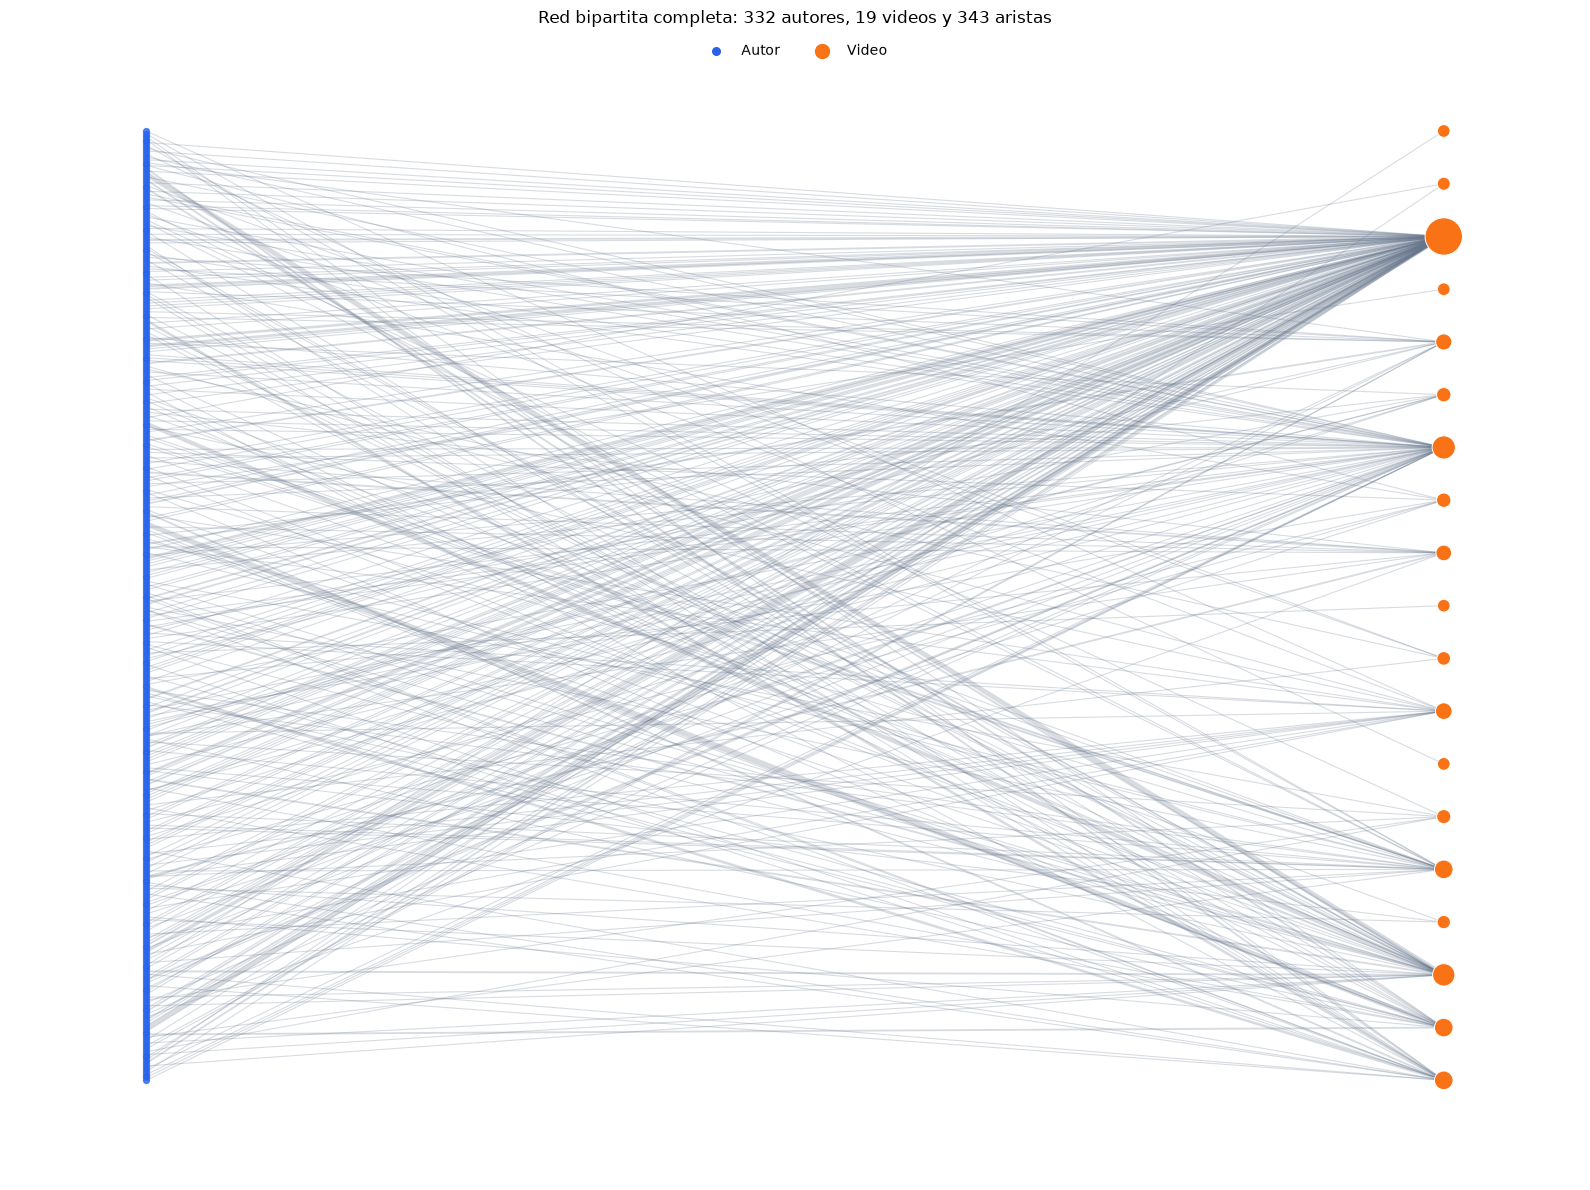

In [4]:
pos = nx.bipartite_layout(B, autores, align="vertical", scale=2)
comentarios_video = [B.nodes[n]["n_comentarios"] for n in videos_red]
anchos = [0.25 + 0.55 * d["weight"] for _, _, d in B.edges(data=True)]

fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_edges(B, pos, width=anchos, alpha=0.25, edge_color="#64748b", ax=ax)
nx.draw_networkx_nodes(
    B, pos, nodelist=autores, node_size=18, node_color="#2563eb", alpha=0.75, ax=ax
)
nx.draw_networkx_nodes(
    B,
    pos,
    nodelist=videos_red,
    node_size=[80 + 4 * n for n in comentarios_video],
    node_color="#f97316",
    edgecolors="white",
    linewidths=0.7,
    ax=ax,
)
ax.scatter([], [], s=30, color="#2563eb", label="Autor")
ax.scatter([], [], s=100, color="#f97316", label="Video")
ax.legend(frameon=False, loc="upper center", ncols=2)
ax.set_title(
    f"Red bipartita completa: {len(autores)} autores, {len(videos_red)} videos y "
    f"{B.number_of_edges()} aristas"
)
ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURAS / "04_red_bipartita_completa.png", dpi=180, bbox_inches="tight")
plt.show()

## 4.5. Significado y límites de una arista

In [5]:
componentes = sorted((len(c) for c in nx.connected_components(B)), reverse=True)
display(Markdown(
    f"La red tiene **{len(componentes)} componentes conexas**. La mayor reúne "
    f"**{componentes[0]} nodos**, equivalentes al **{100 * componentes[0] / B.number_of_nodes():.1f} %** "
    "de la red. Esta fragmentación describe únicamente los comentarios recolectados."
))

La red tiene **10 componentes conexas**. La mayor reúne **286 nodos**, equivalentes al **81.5 %** de la red. Esta fragmentación describe únicamente los comentarios recolectados.

Una arista significa que una cuenta publicó al menos un comentario en un video de la muestra. El peso cuenta cuántos comentarios de esa cuenta se observaron en ese video.

La arista no demuestra amistad, conversación directa, respuesta ni aprobación. `reply_count` no identifica al autor de una respuesta y, por esa razón, no se utilizó para construir enlaces. Tampoco se puede concluir que un autor aislado no participe en otros videos, porque los datos solo cubren una selección de contenido y comentarios.